<div align="center">

## Hierarchical Clustering with Gini prametric

## [S. Mussard](https://sites.google.com/view/cv-stphane-mussard/accueil "Homepage")

</div>

In [ ]:
from GiniAgglomerative import GiniDistance     
from sklearn.cluster import AgglomerativeClustering 
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

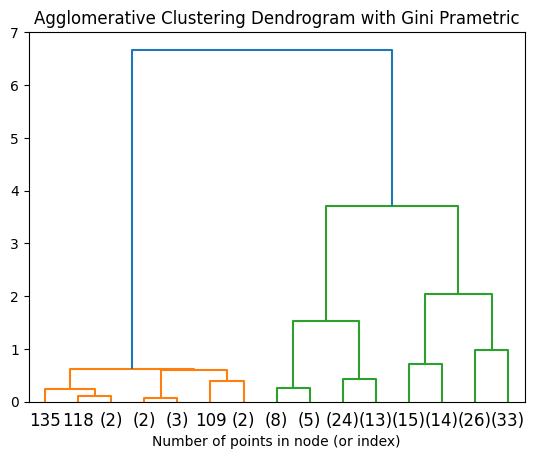

In [ ]:
# Iris Data
iris = load_iris()
X = iris.data
# Instantiation of Gini prametric
gini_distance = GiniDistance(X, gini_param=1.1)
# Fit prametric
gini_distance_matrix = gini_distance.compute_distances(X)
# Fit Agglomerative
model = AgglomerativeClustering(n_clusters=None, distance_threshold=0, metric='precomputed', linkage='complete')
model = model.fit(gini_distance_matrix)
# Plot
plt.title("Agglomerative Clustering Dendrogram with Gini Prametric")
gini_distance.plot_dendrogram(model, truncate_mode="level", p=3)
plt.xlabel("Number of points in node (or index)")
plt.show()


In [11]:
# Fit model for 3 clusters
model = AgglomerativeClustering(n_clusters=3, distance_threshold=None, metric='precomputed', linkage='average')
model = model.fit(gini_distance_matrix)
model.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 0, 0, 0,
       2, 2, 2, 0, 0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 2], dtype=int64)

In [ ]:
from sklearn.metrics import classification_report
# Apply mapping
mapped_labels = gini_distance.map_labels(model.labels_, iris.target)
classif_report = classification_report(iris.target, mapped_labels, target_names=iris.target_names)
print("Report", classif_report)

Report               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.68      1.00      0.81        50
   virginica       1.00      0.52      0.68        50

    accuracy                           0.84       150
   macro avg       0.89      0.84      0.83       150
weighted avg       0.89      0.84      0.83       150



In [13]:
# Compute distances between successive nodes: add 'compute_distances=True'
model = AgglomerativeClustering(n_clusters=None, distance_threshold=0, metric='precomputed', linkage='complete', compute_distances=True)
model = model.fit(gini_distance_matrix)
model.distances_
print(np.argmax(model.distances_))
print(model.distances_.shape)

148
(149,)


In [14]:
model.distances_

array([-0.00000000e+00,  5.40194647e-04,  1.00477487e-03,  1.29293324e-03,
        1.42431059e-03,  1.53579710e-03,  1.61208464e-03,  2.00214328e-03,
        2.11146683e-03,  2.39347204e-03,  2.50431899e-03,  2.56885883e-03,
        2.67205952e-03,  2.78738746e-03,  2.92334435e-03,  3.02313055e-03,
        3.35285005e-03,  3.57901889e-03,  3.62735030e-03,  3.64251759e-03,
        3.79453535e-03,  3.85313272e-03,  4.17756761e-03,  4.33147404e-03,
        4.82864654e-03,  4.87485474e-03,  4.97691683e-03,  5.74972931e-03,
        5.95335035e-03,  6.13474704e-03,  6.14134154e-03,  6.25208481e-03,
        6.41489022e-03,  6.49690935e-03,  6.61303825e-03,  7.99820905e-03,
        8.35388059e-03,  8.48158887e-03,  9.18152608e-03,  9.18394140e-03,
        9.68936820e-03,  1.03061958e-02,  1.06432771e-02,  1.12794020e-02,
        1.15295171e-02,  1.17665794e-02,  1.23606522e-02,  1.24107768e-02,
        1.24494876e-02,  1.26198238e-02,  1.26364499e-02,  1.28040524e-02,
        1.28197412e-02,  

In [15]:
# Euclidean
model = AgglomerativeClustering(n_clusters=3, distance_threshold=None, metric='euclidean', linkage='ward')
model.fit(X)
model.labels_
# Apply mapping
mapped_labels = gini_distance.map_labels(model.labels_, iris.target)
c_report = classification_report(iris.target, mapped_labels, target_names=iris.target_names)
print("Report", c_report)

Report               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.77      0.98      0.86        50
   virginica       0.97      0.70      0.81        50

    accuracy                           0.89       150
   macro avg       0.91      0.89      0.89       150
weighted avg       0.91      0.89      0.89       150



In [16]:
# Outliers ?
gini_distance.outliers(X)

(array([0, 0, 0, 0]), 0)

## Finding Gini-param $\nu$ with PCA

In [17]:
## Optimal Gini param
from Gini_PCA import GiniPca
import torch
model = GiniPca(gini_param=2, n_components=3)
x = torch.DoubleTensor(X)
model.optimal_gini_param(x)

tensor(1.1000)

In [18]:
gini_distance = GiniDistance(X, gini_param=1.1)
# Fit prametric
gini_distance_matrix = gini_distance.compute_distances(X)
# Fit Agglomerative
model = AgglomerativeClustering(n_clusters=3, distance_threshold=None, metric='precomputed', linkage='complete')
model.fit(gini_distance_matrix)
# Apply mapping
mapped_labels = gini_distance.map_labels(model.labels_, iris.target)
c_report = classification_report(iris.target, mapped_labels, target_names=iris.target_names)
print("Report", c_report)

Report               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.57      1.00      0.72        50
   virginica       1.00      0.24      0.39        50

    accuracy                           0.75       150
   macro avg       0.86      0.75      0.70       150
weighted avg       0.86      0.75      0.70       150



## Glass UCI dataset

German, B. (1987). Glass Identification [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5WW2P.

In [19]:
# Glass data UCI
column_names = [
    'Id', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'
]
glass_df = pd.read_csv('glass_data.csv', sep=",")
glass_df.dropna()
glass_df.head(2)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1


In [20]:
X = glass_df[[
    'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']]
X = np.asarray(X)
y = glass_df['Type']
y = y.astype(int) 

In [21]:
# Gini
gini_distance = GiniDistance(X, gini_param=2)
gini_distance_matrix = gini_distance.compute_distances(X)
model_gini = AgglomerativeClustering(n_clusters=6, distance_threshold=None, metric='precomputed', linkage='complete')
model_gini = model_gini.fit(gini_distance_matrix)
# Mapping and classification report
mapped_labels = gini_distance.map_labels(model_gini.labels_, y)
print("Report", classification_report(y, mapped_labels, zero_division=1))

Report               precision    recall  f1-score   support

           1       0.48      1.00      0.65        70
           2       0.57      0.17      0.26        76
           3       1.00      0.00      0.00        17
           5       0.61      0.85      0.71        13
           6       1.00      0.00      0.00         9
           7       0.85      0.76      0.80        29

    accuracy                           0.54       214
   macro avg       0.75      0.46      0.40       214
weighted avg       0.63      0.54      0.46       214



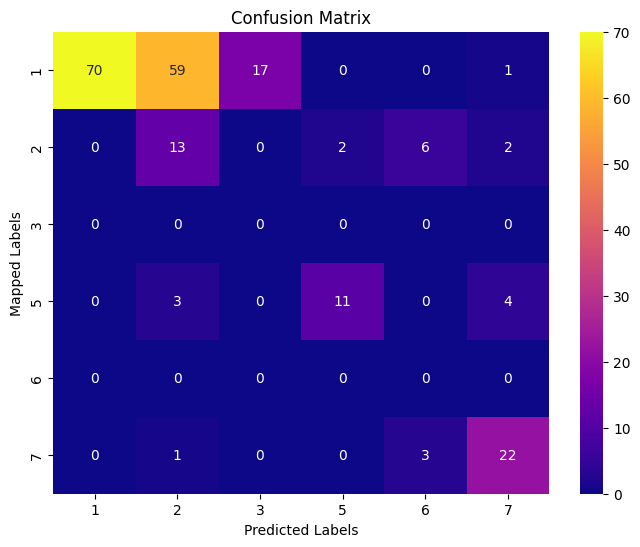

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(mapped_labels, y)
# Plot 
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='plasma', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('Mapped Labels')
plt.show()

In [23]:
# Euclidean
model_euclidean = AgglomerativeClustering(n_clusters=6, distance_threshold=None, metric='euclidean', linkage='complete')
model_euclidean = model_euclidean.fit(X)
# Mapping and report
mapped_labels = gini_distance.map_labels(model_euclidean.labels_, y)
print("Report", classification_report(y, mapped_labels, zero_division=1))

Report               precision    recall  f1-score   support

           1       0.43      1.00      0.60        70
           2       0.48      0.14      0.22        76
           3       1.00      0.00      0.00        17
           5       1.00      0.15      0.27        13
           6       1.00      0.00      0.00         9
           7       0.89      0.83      0.86        29

    accuracy                           0.50       214
   macro avg       0.80      0.35      0.32       214
weighted avg       0.61      0.50      0.41       214



In [24]:
# Euclidean
model_euclidean = AgglomerativeClustering(n_clusters=6, distance_threshold=None, metric='euclidean', linkage='ward')
model_euclidean = model_euclidean.fit(X)
# Mapping and report
mapped_labels = gini_distance.map_labels(model_euclidean.labels_, y)
print("Report", classification_report(y, mapped_labels, zero_division=1))

Report               precision    recall  f1-score   support

           1       0.50      0.23      0.31        70
           2       0.49      0.88      0.63        76
           3       1.00      0.00      0.00        17
           5       0.50      0.85      0.63        13
           6       1.00      0.00      0.00         9
           7       0.92      0.76      0.83        29

    accuracy                           0.54       214
   macro avg       0.73      0.45      0.40       214
weighted avg       0.61      0.54      0.48       214



In [25]:
model = GiniPca(gini_param = 2.4, n_components = 3)
model.eigen_val(x)


tensor([73.6481, 22.5866,  3.2194,  0.5460], dtype=torch.float64)

# Liver data

Liver Disorders [Dataset]. (2016). UCI Machine Learning Repository. https://doi.org/10.24432/C54G67.

In [26]:

liver_data = pd.read_csv('liver.csv', sep=',')
liver_data = liver_data.dropna(how='any') 
liver_data.columns = [
        "Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin", "Alkaline_Phosphotase",
        "Alamine_Aminotransferase", "Aspartate_Aminotransferase", "Total_Proteins",
        "Albumin", "Albumin_and_Globulin_Ratio", "Dataset"
    ]

X = liver_data[[
        "Aspartate_Aminotransferase", "Total_Proteins",
        "Albumin", "Albumin_and_Globulin_Ratio"
    ]]
X = np.asarray(X)
y = liver_data[["Dataset"]]
y = np.where(y == 2, 0, y)
y = y.astype(int) 

# German Credit 

South German Credit [Dataset]. (2020). UCI Machine Learning Repository. https://doi.org/10.24432/C5QG88.

In [27]:
# UCI "German credit dataset"
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

# Column names based on the documentation
column_names = [
    "Status", "Duration", "CreditHistory", "Purpose", "CreditAmount",
    "Savings", "Employment", "InstallmentRate", "PersonalStatus", "OtherDebtors",
    "ResidenceDuration", "Property", "Age", "OtherInstallmentPlans", "Housing",
    "ExistingCredits", "Job", "LiablePeople", "Telephone", "ForeignWorker", "Risk"
]

# Load the dataset into a DataFrame
german_credit = pd.read_csv(url, sep=' ', header=None, names=column_names)

# Define X (quantitative) and y
X = german_credit[
    ["Duration", 
    "CreditAmount", 
    "InstallmentRate", 
    "ResidenceDuration", 
    "Age", 
    "ExistingCredits", 
    "LiablePeople"]
]
X = np.asarray(X)
y = german_credit[["Risk"]]
y = np.where(y == 1, 0, y)
y = np.where(y == 2, 1, y)

# Heart Disease

Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X.

In [ ]:
# Load dataset (modify the path to your local file or use an online URL)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
heart_data = pd.read_csv(url, header=None, names=column_names)

heart_data = heart_data.dropna(how='any') 
heart_data.dtypes


age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object